In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures

import phik
from phik.report import plot_correlation_matrix

In [2]:
from sklearn import datasets 
fetch_california_housing = datasets.fetch_california_housing()
print(fetch_california_housing.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [3]:
fetch_california_housing.feature_names

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

    - MedInc        Средний доход в группе кварталов
    - HouseAge      Средний возраст семьи в группе кварталов
    - AveRooms      Среднее количество комнат в семье
    - AveBedrms     Среднее количество спален в семье
    - Population    Численность населения в группе кварталов
    - AveOccup      Среднее количество членов семьи, проживающих в кварталах
    - Latitude      Широта группы кварталов
    - Longitude     Долгота группы кварталов
    
Целевой переменной является средняя стоимость дома для районов Калифорнии, выраженная в сотнях тысяч долларов (100 000 долларов США).

Этот набор данных был получен на основе переписи населения США 1990 года с использованием одной строки для каждой
группы переписных блоков. Многоквартирный дом - это наименьшая географическая единица, для которой в США используются данные переписи населения.

Бюро переписи населения публикует выборочные данные (в многоквартирном доме обычно проживает
от 600 до 3000 человек).

Домохозяйство - это группа людей, проживающих в одном доме. Поскольку среднее
количество комнат и спальных комнат в этом наборе данных указано на домохозяйство, эти
столбцы могут иметь неожиданно большие значения для групп кварталов с небольшим количеством домохозяйств
и большим количеством пустующих домов, таких как курорты для отдыха.

In [4]:
fetch_california_housing.target_names

['MedHouseVal']

# 1 модель - удаление пропусков

In [5]:
data_x_1 = pd.DataFrame(fetch_california_housing.data, columns=fetch_california_housing.feature_names)
data_x_1.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [6]:
data_y_1=pd.DataFrame(fetch_california_housing.target, columns=fetch_california_housing.target_names)
data_y_1.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [7]:
data_x_1.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

In [8]:
data_x_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


Пропусков в данных нет

In [9]:
X_train, X_test, y_train, y_test = train_test_split(data_x_1,data_y_1, test_size = 0.2, random_state=42)

In [10]:
model = LinearRegression()

In [11]:
model.fit(X_train, y_train)

LinearRegression()

In [12]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [13]:
rmse_1_test = root_mean_squared_error(y_test,y_pred_test)
print(rmse_1_test)

0.7455813830127761


In [14]:
rmse_1_train = root_mean_squared_error(y_train,y_pred_train)
print(rmse_1_train)

0.7196757085831575


In [15]:
r2_1_test = r2_score(y_test,y_pred_test)
print(r2_1_test)

0.5757877060324511


In [16]:
r2_1_train = r2_score(y_train,y_pred_train)
print(r2_1_train)

0.6125511913966952


# 2 модель - исследование распределия целевого признака и корреляции признаков

In [17]:
data_x_2 = pd.DataFrame(fetch_california_housing.data, columns=fetch_california_housing.feature_names)

In [18]:
data_y_2=pd.DataFrame(fetch_california_housing.target, columns=fetch_california_housing.target_names)

array([[<Axes: title={'center': 'MedHouseVal'}>]], dtype=object)

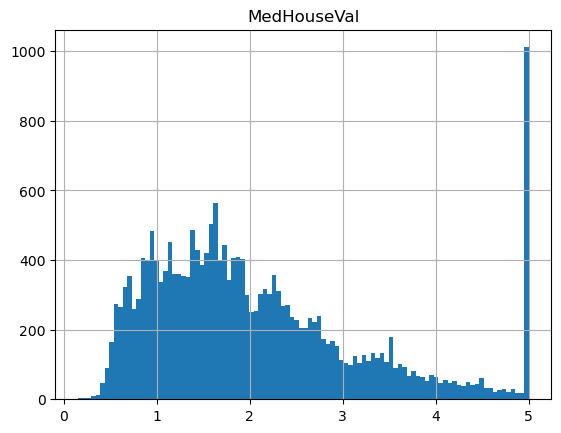

In [19]:
data_y_2.hist(bins=100)

<Axes: >

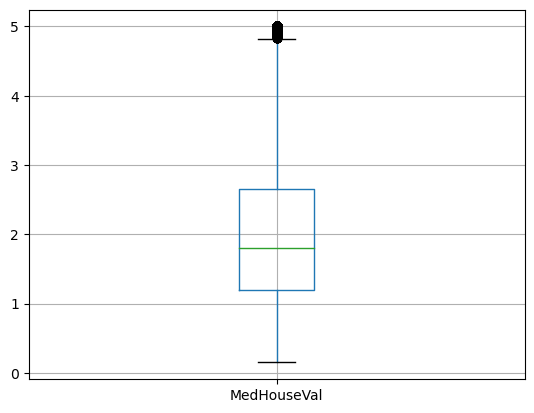

In [20]:
data_y_2.boxplot()

График распределения смещен в левую сторону, судя по графику есть выбросы в правой части графика. Boxplot также подтверждает наличие выбросов в целевой переменной.

In [21]:
data_all_2 = pd.concat([data_x_2,data_y_2], axis=1)

interval columns not set, guessing: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


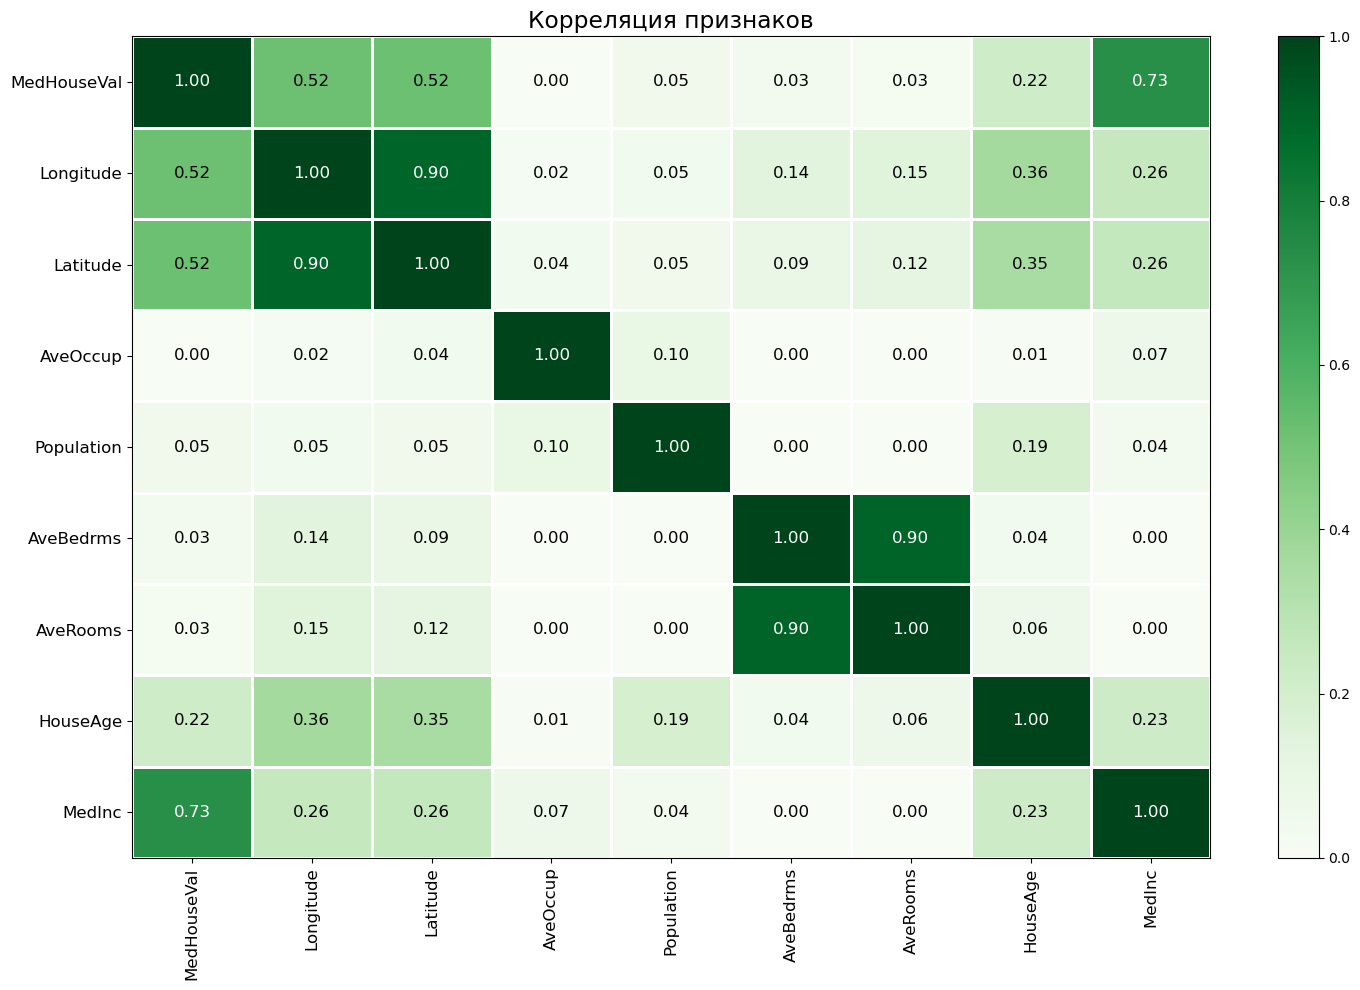

In [22]:
# Формирование матрицы phik
df_for_phik = data_all_2.phik_matrix()
# тепловая карта
plot_correlation_matrix(
    df_for_phik.values,
    x_labels=df_for_phik.columns,
    y_labels=df_for_phik.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'Корреляция признаков',
    fontsize_factor=1.2,
    figsize=(15, 10)
)

Наблюдается высокая корреляция (мультиколлинеарность) между Latitude и Longitude. Необходимо удалить один из признаков.

Целевой признак - стоимость дома имеет наибольшую корреляцию с признаков MedInc - средний доход, это логично.

In [23]:
data_x_2 = data_x_2.drop(['Longitude'], axis=1)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(data_x_2,data_y_2, test_size = 0.2, random_state=42)

In [25]:
model_2 = LinearRegression()

In [26]:
model_2.fit(X_train, y_train)

LinearRegression()

In [27]:
y_pred_train_2 = model_2.predict(X_train)
y_pred_test_2 = model_2.predict(X_test)

In [28]:
rmse_2_train = root_mean_squared_error(y_train,y_pred_train_2)
print(rmse_2_train)

0.7766448095288707


In [29]:
print(rmse_1_train)

0.7196757085831575


In [30]:
r2_2_train = r2_score(y_train,y_pred_train_2)
print(r2_2_train)

0.5487829208700852


In [31]:
print(r2_1_train)

0.6125511913966952


# 3 модель - исследуем оставшиеся признаки на выбросы и удалим их при наличии

<Axes: >

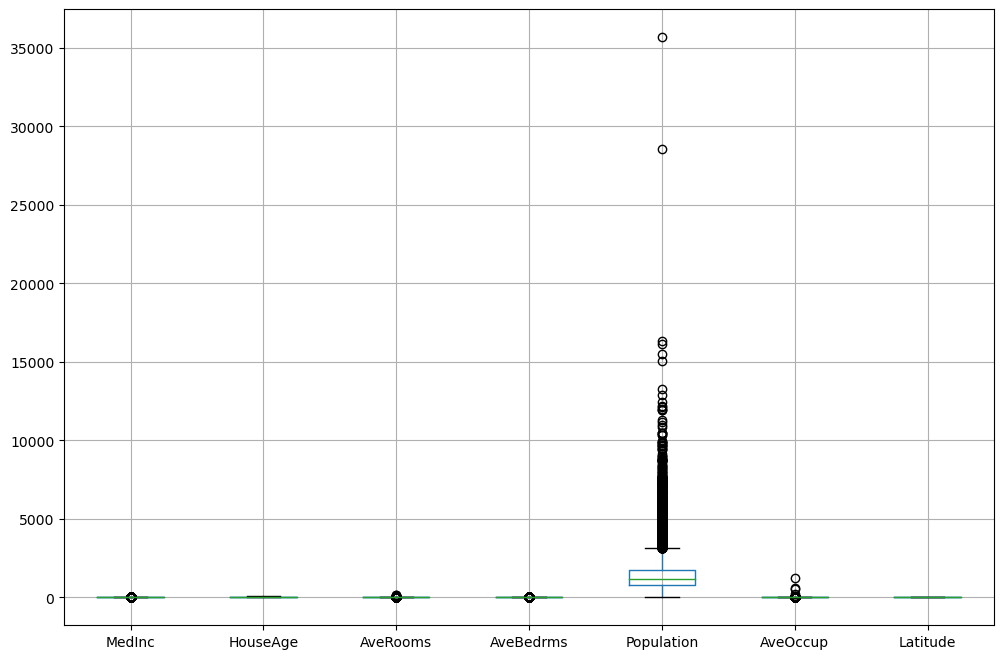

In [32]:
plt.figure(figsize = (12,8))
data_x_2.boxplot()

<Axes: >

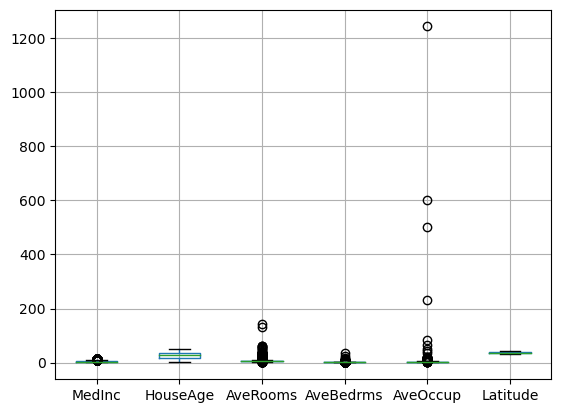

In [33]:
data_x_2.drop(['Population'], axis=1).boxplot()

Выбросы есть почти во всех полях.
Удалим в цикле все выбросы используя 1,5 межквартильного размаха.

In [34]:
data_all_3 = pd.concat([data_x_2,data_y_2], axis=1)

In [35]:
for col in data_all_3.columns:
    q1 = data_all_3[col].quantile(0.25)
    q3 = data_all_3[col].quantile(0.75)
    iqr = q3 - q1
    data_all_3 = data_all_3[(data_all_3[col] < q3 + 1.5 * iqr) & (data_all_3[col] > q1 - 1.5 * iqr)]

In [36]:
# Разделение датафреймов на целевую и нецелевую выборку
data_x_3 = data_all_3.drop(['MedHouseVal'], axis=1)
data_y_3 = data_all_3['MedHouseVal']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(data_x_3,data_y_3, test_size = 0.2, random_state=42)

In [38]:
model_3 = LinearRegression()
model_3.fit(X_train, y_train)

LinearRegression()

In [39]:
y_pred_train_3 = model_3.predict(X_train)
y_pred_test_3 = model_3.predict(X_test)

In [40]:
rmse_3_train = root_mean_squared_error(y_train,y_pred_train_3)
print(rmse_3_train)
print(rmse_2_train)
print(rmse_1_train)

0.6090724622390574
0.7766448095288707
0.7196757085831575


In [41]:
r2_3_train = r2_score(y_train,y_pred_train_3)
print(r2_3_train)
print(r2_2_train)
print(r2_1_train)

0.5724979973032129
0.5487829208700852
0.6125511913966952


# 4 модель - Изменим несколько признаков математически

2 модель дала самые плохие результаты (rmse увеличился, а r2 снизился).
Поэтому для 4 модели возьмем все признаки и удалим выбросы. 

In [42]:
data_x_4 = pd.DataFrame(fetch_california_housing.data, columns=fetch_california_housing.feature_names)

In [43]:
data_y_4=pd.DataFrame(fetch_california_housing.target, columns=fetch_california_housing.target_names)

In [44]:
data_all_4 = pd.concat([data_x_4,data_y_4], axis=1)

In [45]:
#удаление выбросов
for col in data_all_4.columns:
    q1 = data_all_4[col].quantile(0.25)
    q3 = data_all_4[col].quantile(0.75)
    iqr = q3 - q1
    data_all_4 = data_all_4[(data_all_4[col] < q3 + 1.5 * iqr) & (data_all_4[col] > q1 - 1.5 * iqr)]

In [46]:
data_all_4.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,16231.000000,16231.000000,16231.000000,16231.000000,16231.000000,16231.000000,16231.000000,16231.00000,16231.000000
mean,3.648489,29.412236,5.150766,1.046890,1278.952806,2.868588,35.669733,-119.62364,1.916565
std,1.434752,12.187316,1.036667,0.065830,633.554803,0.626141,2.141438,1.99542,0.929862
min,0.536000,1.000000,2.133929,0.869822,5.000000,1.161290,32.540000,-124.35000,0.149990
25%,2.559200,19.000000,4.424242,1.002732,817.000000,2.440371,33.940000,-121.81000,1.183000
50%,3.487100,30.000000,5.138418,1.043478,1164.000000,2.817391,34.290000,-118.60000,1.768000
75%,4.569650,38.000000,5.843501,1.088385,1644.000000,3.248210,37.730000,-118.03000,2.480000
max,8.011300,52.000000,8.273632,1.232975,3183.000000,4.571046,41.950000,-114.57000,4.669000


In [47]:
poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(data_all_4)

In [48]:
df_poly = pd.DataFrame(poly_features, columns=poly.get_feature_names_out())

In [49]:
df_poly.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal', 'MedInc^2', 'MedInc HouseAge',
       'MedInc AveRooms', 'MedInc AveBedrms', 'MedInc Population',
       'MedInc AveOccup', 'MedInc Latitude', 'MedInc Longitude',
       'MedInc MedHouseVal', 'HouseAge^2', 'HouseAge AveRooms',
       'HouseAge AveBedrms', 'HouseAge Population', 'HouseAge AveOccup',
       'HouseAge Latitude', 'HouseAge Longitude', 'HouseAge MedHouseVal',
       'AveRooms^2', 'AveRooms AveBedrms', 'AveRooms Population',
       'AveRooms AveOccup', 'AveRooms Latitude', 'AveRooms Longitude',
       'AveRooms MedHouseVal', 'AveBedrms^2', 'AveBedrms Population',
       'AveBedrms AveOccup', 'AveBedrms Latitude', 'AveBedrms Longitude',
       'AveBedrms MedHouseVal', 'Population^2', 'Population AveOccup',
       'Population Latitude', 'Population Longitude', 'Population MedHouseVal',
       'AveOccup^2', 'AveOccup Latitude', 'AveOccup Longitude',
   

In [50]:
# Разделение датафреймов на целевую и нецелевую выборку
data_x_4 = data_all_4.drop(['MedHouseVal'], axis=1)
data_y_4 = data_all_4['MedHouseVal']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(data_x_4,data_y_4, test_size = 0.2, random_state=42)

In [52]:
model_4 = LinearRegression()
model_4.fit(X_train, y_train)

LinearRegression()

In [53]:
y_pred_train_4 = model_4.predict(X_train)
y_pred_test_4 = model_4.predict(X_test)

In [54]:
rmse_4_train = root_mean_squared_error(y_train,y_pred_train_4)
print(rmse_4_train)

0.559292766191944


In [55]:
r2_4_train = r2_score(y_train,y_pred_train_4)
print(r2_4_train)

0.6395221124117257


# Сводная таблица с результатами

In [56]:
# Создаем DataFrame 
finish_table = pd.DataFrame({
    'Model': [1, 2, 3, 4],
    'RMSE': [rmse_1_train, rmse_2_train, rmse_3_train, rmse_4_train],
    'R2': [r2_1_train, r2_2_train, r2_3_train, r2_4_train],
    'Comment':["Все признаки без изменений, пропусков нет","Удален признак Longitude"\
              ,"Удален признак Longitude и удалены выбросы"\
              ,"Все признаки, удалены выбросы + Сгенерированы признаки из всех полиномиальных комбинаций"]
})

pd.set_option('display.max_colwidth', None)

In [57]:
finish_table

,Model,RMSE,R2,Comment
0,1,0.719676,0.612551,"Все признаки без изменений, пропусков нет"
1,2,0.776645,0.548783,Удален признак Longitude
2,3,0.609072,0.572498,Удален признак Longitude и удалены выбросы
3,4,0.559293,0.639522,"Все признаки, удалены выбросы + Сгенерированы признаки из всех полиномиальных комбинаций"


# Вывод

Были рассчитаны 4 разные модели.

1 модель, в которой были данные в неизменном виде дала не плохие результаты, она оказалась лучше чем вторая модель, в которой был удален признак Longitude.

Удаление выбросов улучшило показатели относительно 2-ой модели.

Поэтому для 4 модели, в которой создаются новые признаки, был выбран датасет, включающий все признаки и в котором удалены выбросы. 
В модели были сгенерированы новые признаки из всех полиномиальных комбинаций. Данная модель показала наилучшие результаты.

У нее наименьший RMSE (наименьший средний размер ошибок) 0,56 и наибольший R2 - 0,64, данная модель объясняет наибольшее кол-во вариаций. 